In [ ]:
# data collection and preprocessing

import pandas as pd
from sklearn.preprocessing import LabelEncoder

# get the data from the csv
df = pd.read_csv('car_price_prediction_.csv')


# delete the columns that dont matter for the math part 
# model and car id are useless here
df_clean = df.drop(['Car ID', 'Model'], axis=1)

# regression cant read words so we make them numbers
# this part create those dummy variables for the brand and fuel type etc
df_processed = pd.get_dummies(df_clean, columns=['Brand', 'Fuel Type', 'Transmission', 'Condition'], drop_first=True)

print("done with cleaning. the shape is:", df_processed.shape)

done with cleaning. the shape is: (2500, 16)


In [12]:
df.tail()

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
2495,2496,Audi,2020,2.4,Petrol,Automatic,22650,Like New,61384.10,Q5
2496,2497,Audi,2001,5.7,Hybrid,Manual,77701,Like New,24710.35,A3
2497,2498,Ford,2021,1.1,Hybrid,Manual,272827,Like New,29902.45,Fiesta
2498,2499,Audi,2002,4.5,Diesel,Manual,229164,Like New,46085.67,Q5
2499,2500,Toyota,2005,4.6,Diesel,Automatic,80978,Used,16594.14,RAV4


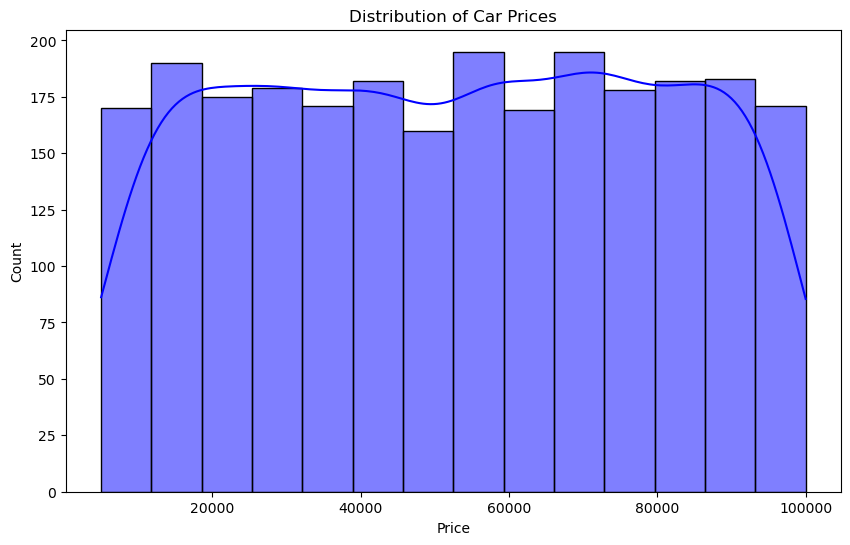

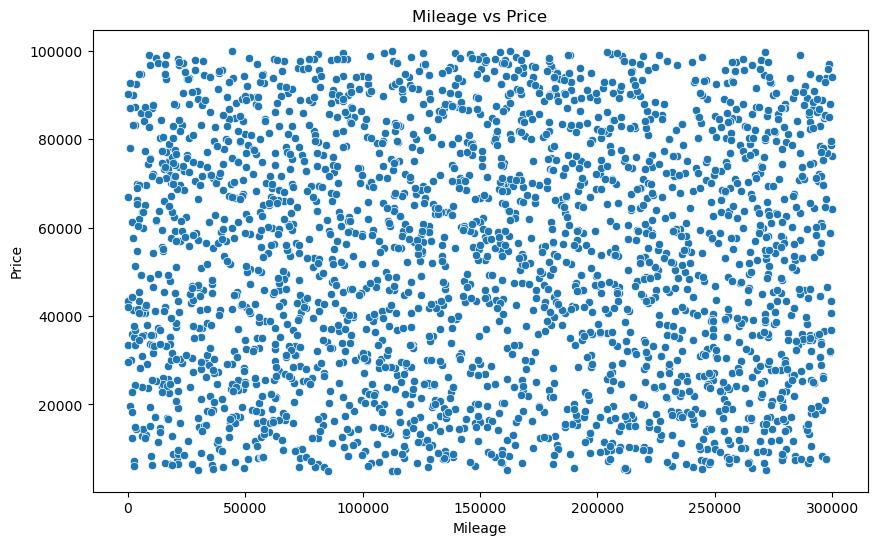

In [7]:
# explarotary data analysis

import matplotlib.pyplot as plt
import seaborn as sns

# check how prices are spread out in the data
plt.figure(figsize=(10, 6))
sns.histplot(df['Price'], kde=True, color='blue')
plt.title('Distribution of Car Prices')
plt.savefig('price_dist.png')

# see if more mileage actually means lower price (it should)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Mileage', y='Price', data=df)
plt.title('Mileage vs Price')
plt.savefig('mileage_vs_price.png')

In [8]:
# linear regression modeling

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# X is the stuff we know, y is the price we want to find
X = df_processed.drop('Price', axis=1)
y = df_processed['Price']

# hide 20% of data to test the model later so we dont cheat
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# start the actual linear regression here
model = LinearRegression()
model.fit(X_train, y_train)

# check if the model is actually good or just guessing
predictions = model.predict(X_test)
r2 = r2_score(y_test, predictions)
mse = mean_squared_error(y_test, predictions)

print(f"R2 score is: {r2:.4f}")
print(f"mse error: {mse:.2f}")

R2 score is: -0.0038
mse error: 760452909.18
